In [2]:
import pandas as pd

In [3]:
titanic_df = pd.read_csv("titanic/train.csv")

In [4]:
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# Outlier Handling

* Using IQR

<Axes: >

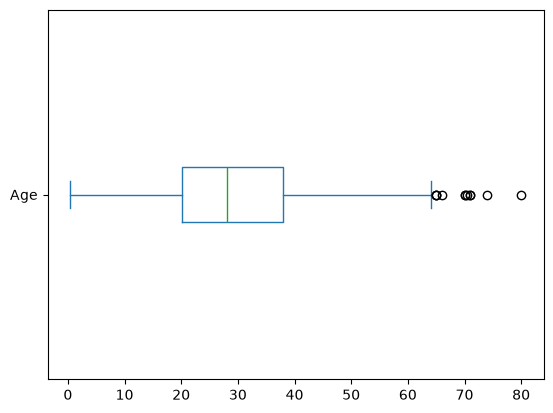

In [5]:
titanic_df.Age.plot(kind = "box", vert = False)

In [6]:
Q1 = titanic_df.Age.quantile(q = 0.25)
Q3 = titanic_df.Age.quantile(q = 0.75)

IQR = Q3 - Q1

maximum = Q3 + (1.5 * IQR)
minimum = Q1 - (1.5 * IQR)

In [7]:
Q1

np.float64(20.125)

In [8]:
Q3

np.float64(38.0)

In [9]:
IQR

np.float64(17.875)

In [10]:
print(maximum, minimum)

64.8125 -6.6875


In [11]:
titanic_df.Age[(titanic_df.Age > maximum) | (titanic_df.Age < maximum)]

0      22.0
1      38.0
2      26.0
3      35.0
4      35.0
       ... 
885    39.0
886    27.0
887    19.0
889    26.0
890    32.0
Name: Age, Length: 714, dtype: float64

<Axes: >

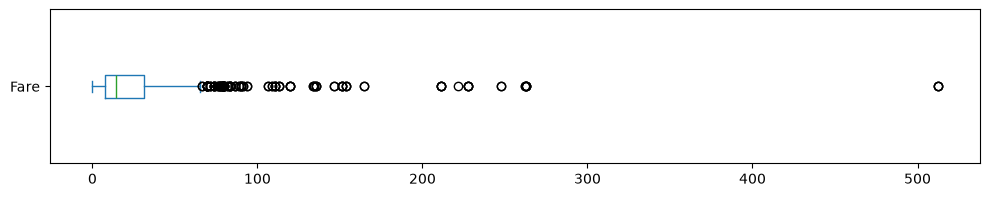

In [12]:
titanic_df.Fare.plot(kind = "box", vert = False, figsize = (12,2))

In [13]:
Q1 = titanic_df.Fare.quantile(q = 0.25)
Q3 = titanic_df.Fare.quantile(q = 0.75)

print(Q1, Q3)

7.9104 31.0


In [14]:
IQR = Q3 - Q1

maximum = Q3 + (1.5 * IQR)
minimum = Q1 - (1.5 * IQR)

In [15]:
IQR

np.float64(23.0896)

In [16]:
print(maximum, minimum)

65.6344 -26.724


* Using Z-score

In [19]:
z_score = abs(titanic_df.Age - titanic_df.Age.mean()) / titanic_df.Age.std()
z_score

0      0.530005
1      0.571430
2      0.254646
3      0.364911
4      0.364911
         ...   
886    0.185807
887    0.736524
888         NaN
889    0.254646
890    0.158392
Name: Age, Length: 891, dtype: float64

In [21]:
titanic_df[z_score > 2.5]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
96,97,0,1,"Goldschmidt, Mr. George B",male,71.0,0,0,PC 17754,34.6542,A5,C
116,117,0,3,"Connors, Mr. Patrick",male,70.5,0,0,370369,7.7500,NaN,Q
493,494,0,1,"Artagaveytia, Mr. Ramon",male,71.0,0,0,PC 17609,49.5042,NaN,C
630,631,1,1,"Barkworth, Mr. Algernon Henry Wilson",male,80.0,0,0,27042,30.0000,A23,S
672,673,0,2,"Mitchell, Mr. Henry Michael",male,70.0,0,0,C.A. 24580,10.5000,NaN,S
745,746,0,1,"Crosby, Capt. Edward Gifford",male,70.0,1,1,WE/P 5735,71.0000,B22,S
851,852,0,3,"Svensson, Mr. Johan",male,74.0,0,0,347060,7.7750,NaN,S
